In [2]:
import scanpy as sc

In [3]:
# Load data
adata = sc.read_h5ad("/mnt/nfs/EMBO/Integration/data/Hickey2023/hickey.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 4141747 × 21332
    obs: 'sample_id', 'barcode', 'SampleNameOnly', 'Donor', 'Multiome', 'Location', 'n_counts'
    var: 'n_cells'

## QC metrics

In [ ]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [ ]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

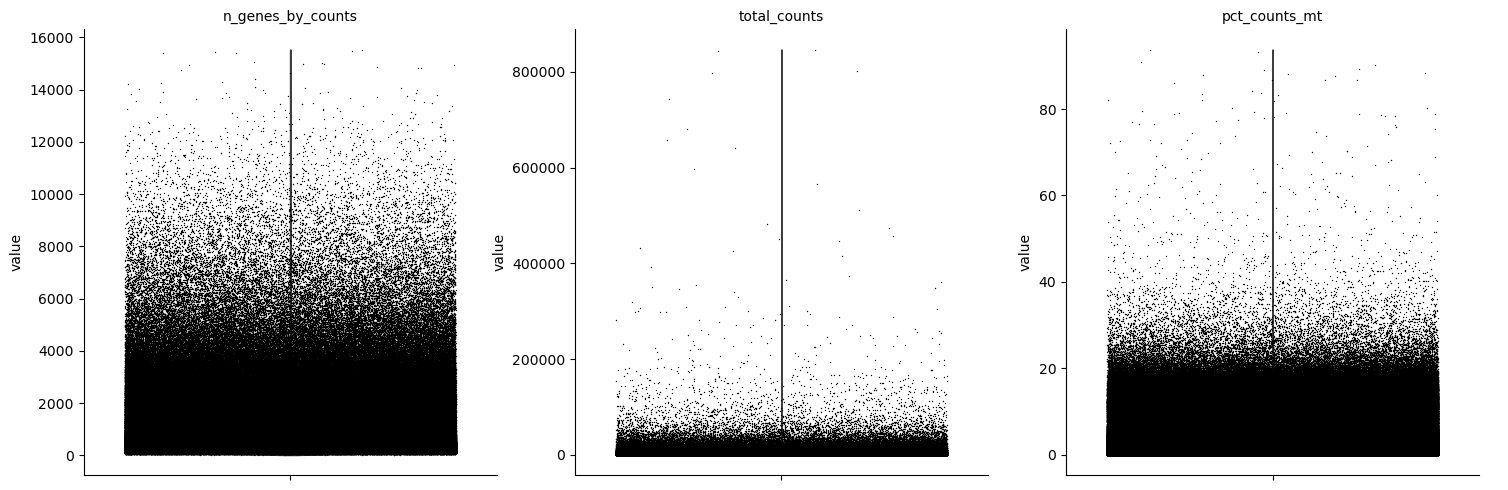

In [12]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

## Doublet detection

In [ ]:
sc.pp.scrublet(adata, batch_key="sample_id")

/mnt/nfs/EMBO/miniforge3/envs/scanpy2/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [10]:
adata

AnnData object with n_obs × n_vars = 4141747 × 21332
    obs: 'sample_id', 'barcode', 'SampleNameOnly', 'Donor', 'Multiome', 'Location', 'n_counts', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scrublet'

In [11]:
adata.write_h5ad("/mnt/nfs/EMBO/Integration/data/Hickey2023/hickey_QCmetric.h5ad")